# McGinley Dynamic — a quantitative teardown
### Daily total-return bars · MD(14) price-cross · the quartic-brake mechanism · HAC inference · permutation placebo · SMA/EMA head-to-head

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cuts_whipsaws_%26_beats_a_plain_MA%3F: Mixed](https://img.shields.io/badge/Cuts_whipsaws_%26_beats_a_plain_MA%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test the mechanism directly (does the `(P/MD)^4` brake actually reduce tracking distance and lag?), then whether the MD(14) price-cross timing rule beats buy-and-hold, beats the matched SMA(14)/EMA(14) rules, and fires fewer false signals — across five liquid daily tapes.

> **Not investment advice.** Real data: Yahoo daily total-return bars, full history to 2026-06-30, as-of **2026-06-30**; the offline core runs the deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `💡 In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from mcginley_dynamic import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "XLE"]
ASOF = data.AS_OF
MD_N = 14

def _have_cache():
    return all(os.path.exists(data._cache_path(t)) for t in TICKERS)

HAVE_REAL = _have_cache()

def tape(t):
    return data.load_real(t, fetch=False, asof=ASOF)

print("real daily cache present:", HAVE_REAL)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'n_spy': 8411, 'yrs': 33.4, 'md_n': 14, 'td_md': 1.981, 'td_sma': 1.535, 'td_ema': 1.327, 'step_price': 120.0, 'step_md': 104.04, 'step_sma': 108.57, 'step_ema': 111.52, 'step_pct_md': 20.2, 'step_pct_sma': 42.9, 'step_pct_ema': 57.6, 'md_sharpe': 0.38, 'md_cagr': 3.81, 'md_dd': -49.1, 'sma_sharpe': 0.238, 'sma_cagr': 2.07, 'sma_dd': -57.6, 'ema_sharpe': 0.267, 'ema_cagr': 2.4, 'ema_dd': -48.0, 'bh_sharpe': 0.647, 'bh_cagr': 10.83, 'bh_dd': -55.2, 'md_spread': -3.01, 'md_t': -3.55, 'sma_spread': -3.7, 'sma_t': -4.42, 'ema_spread': -3.57, 'ema_t': -4.22, 'md_sw': 25.5, 'sma_sw': 36.5, 'ema_sw': 38.3, 'md_tim': 70, 'md_spread_gross': -2.51, 'md_t_gross': -2.98, 'diff_md_sma_bps': 0.69, 'diff_md_sma_t': 1.43, 'diff_md_ema_bps': 0.56, 'diff_md_ema_t': 1.46, 'perm_obs': -2.51, 'perm_placebo': -1.43, 'perm_p': 0.9895, 'cost': [0.0, 2.0, 5.0, 10.0], 'cost_sharpe': [0.489, 0.445, 0.38, 0.27], 'cost_spread': [-2.51, -2.71, -3.01, -3.52], 'cost_t': [-2.98, -3.21, -3.55, -4.1], 'tick': ['SPY', 'QQQ', 'AAPL', 'MSFT', 'XLE'], 'tick_md': [0.38, 0.47, 0.632, 0.494, 0.269], 'tick_bh': [0.647, 0.521, 0.623, 0.821, 0.428], 'tick_spread': [-3.01, -2.29, -2.69, -5.89, -2.78], 'tick_t': [-3.55, -1.81, -1.7, -5.35, -1.89], 'tick_md_sma_t': [1.43, 2.38, 0.13, 0.75, 1.26], 'tick_md_ema_t': [1.46, 2.75, -0.3, 0.69, 2.09], 'tick_md_sw': [25.5, 26.0, 23.5, 26.7, 29.6], 'tick_sma_sw': [36.5, 36.6, 33.1, 37.3, 36.6], 'tick_ema_sw': [38.3, 39.8, 35.7, 40.9, 42.4], 'h1_md': 0.234, 'h1_bh': 0.455, 'h1_spread': -2.45, 'h1_t': -1.89, 'h2_md': 0.572, 'h2_bh': 0.872, 'h2_spread': -3.47, 'h2_t': -3.09, 'ls_sharpe': -0.178, 'ls_spread': -6.08, 'ls_t': -3.58, 'syn_null_mean': -0.39, 'syn_null_sd': 1.12, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_edge': [0.3, 0.6, 1.0], 'syn_spread': [12.27, 26.27, 13.06], 'syn_t': [9.86, 15.23, 8.27], 'syn_sharpe': [2.33, 4.72, 1.66]}


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | MD active spread vs buy&hold **-3.01 bps/day**, HAC *t* = **-3.55** (gross *t* = -2.98); permutation *p* = **0.9895**; negative on all 5 tapes & both halves. |
| **Tradability** | `MIRAGE` | Net Sharpe **0.38** vs buy&hold **0.647**; loses gross; long/short Sharpe **-0.178**. |
| **Cuts whipsaws & beats a plain MA?** | `MIXED` | **25.5** switches/yr vs SMA **36.5** / EMA **38.3** (~30% fewer, genuinely) — but tracking distance is *worse* (1.98% vs EMA 1.33%) and only 3/10 basket head-to-heads clear *t* = 2. |

> 💡 In plain words: the brake mechanism is real and it does cut trade count — but it brakes by tracking price *more loosely*, not by being smarter about when to turn, and the fewer trades don't add up to a certified edge.

## 1 · The claim, steelmanned

John McGinley's Dynamic is a recursive filter:

$$\text{MD}_t = \text{MD}_{t-1} + \frac{P_t - \text{MD}_{t-1}}{N \cdot (P_t / \text{MD}_{t-1})^4}$$

with $N$ McGinley's own stated nominal period (14 for daily data). The pitch is that the quartic ratio term makes the *effective smoothing constant* rise when price is running (so the line "keeps pace") and fall in quiet markets (so it doesn't overreact to noise) — an auto-tuning EMA. Turned into a long/flat rule ($d_t = \mathbb{1}[P_t > \text{MD}_t]$) and raced against the matched SMA(14) and EMA(14) rules and buy-and-hold, the hypotheses:

- **H₀ (mechanism).** MD tracks price more tightly than SMA/EMA of the same $N$ (lower mean $|P-\text{line}|/P$) and reacts *faster* to a shock.
- **H₁ (signal).** $\mathbb{E}[r^{\text{strat}}_t - r^{\text{B\&H}}_t] > 0$ — the active spread is positive.
- **H₂ (beats SMA/EMA).** Net Sharpe$(\text{MD}) > $ Net Sharpe$(\text{SMA/EMA})$, certified at HAC *t* ≥ 2 on the head-to-head spread.
- **H₃ (fewer false signals).** switches/yr$(\text{MD}) < $ switches/yr$(\text{SMA/EMA})$.

We find **H₀ rejected** (tracking distance and step-response both run backwards), **H₁ rejected** (significantly negative), **H₂ not certified** (positive on paper, *t* < 2 on 8 of 10 basket comparisons), and **H₃ confirmed** (a genuine ~30% cut) — the one leg of the folklore that survives, on a mechanism that doesn't work the way it's sold.

## 2 · So what? — what rides on each answer

McGinley Dynamic is marketed as strictly different from the desk's other "smarter MA" claims: not a lag-cancelling extrapolation (DEMA/TEMA, HMA) but a *negative-feedback brake*. If H₀-H₃ all held, it would be the first indicator on this bench to actually deliver "fewer, better signals." The interesting result here is not just another `None`/`Mirage` — it's that the mechanism runs in the *opposite direction* from its own marketing copy (more lag, not less) while still delivering on the *outcome* it's sold on (fewer whipsaws) — a useful reminder that a plausible-sounding mechanism can be empirically backwards and still coincidentally get one prediction right.

## 3 · How we'd know — the protocol

- **Indicator.** McGinley Dynamic(N=14) — McGinley's own stated default for daily data; benchmarks SMA(14) and EMA(14) at the *same* N so the race is fair.
- **Mechanism checks (no trading).** Mean $|P_t - \text{line}_t|/P_t$ on the real SPY tape; a deterministic +20% step response (flat → jump → flat), gap-closed at +5 bars.
- **Rule.** Long/flat: $d_t = \mathbb{1}[P_t > \text{line}_t]$ for each of MD/SMA/EMA. A long/short variant flips flat → −1.
- **Execution lag.** One `shift`: position formed on the close of $t$ earns the close-to-close return of $t+1$. Stated once, applied once.
- **Costs.** One-way × NAV on $|d_t - d_{t-1}|$ turnover; short legs pay 50 bps/yr borrow.
- **Signal test.** HAC (Newey-West) one-sample *t* on the daily active spread $r^{\text{strat}} - r^{\text{B\&H}}$ — excess-vs-excess by construction — plus the MD-minus-SMA and MD-minus-EMA head-to-head spreads.
- **Placebo.** Circular-shift the realised MD position path 2,000× (kills timing, keeps turnover/bias); one-sided *p* on the gross spread.
- **Robustness.** Cost sweep, per-instrument, first-vs-second-half split, long/short.
- **Positive control.** Synthetic tape with a *planted* regime-switching trend, 20-seed null.

Five tapes: SPY, QQQ, AAPL, MSFT, XLE — full history to 2026-06-30 (SPY n = 8,411).

## 4 · The teardown

### 4a · The mechanism, isolated from any trading rule

Before any P&L, does the formula do what it says? Mean tracking distance on the real tape, and a clean deterministic step.

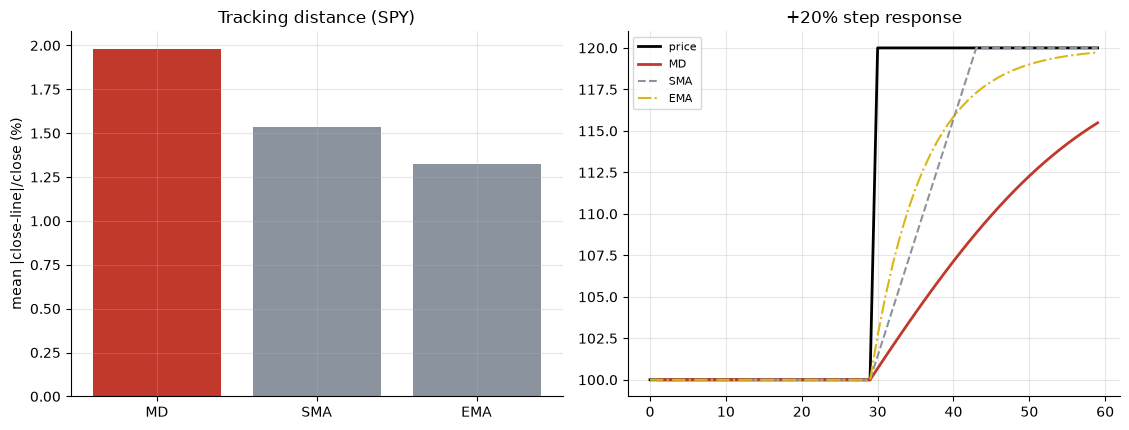

tracking distance: MD 1.981%  SMA 1.535%  EMA 1.327%
5 bars post-jump: MD=104.04  SMA=108.57  EMA=111.52  (price=120.0)


In [2]:
if HAVE_REAL:
    close = tape('SPY')['close']
    td = st.tracking_distance(close, n=MD_N)
else:
    td = {'MD': R['td_md'], 'SMA': R['td_sma'], 'EMA': R['td_ema']}
sr = st.step_response(n=MD_N)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.4))
a1.bar(['MD','SMA','EMA'], [td['MD'], td['SMA'], td['EMA']], color=[RED, GREY, GREY])
a1.set_ylabel('mean |close-line|/close (%)'); a1.set_title('Tracking distance (SPY)')
a2.plot(sr.index, sr['price'], c='k', lw=2, label='price')
a2.plot(sr.index, sr['MD'], c=RED, lw=2, label='MD')
a2.plot(sr.index, sr['SMA'], c=GREY, ls='--', label='SMA')
a2.plot(sr.index, sr['EMA'], c=AMBER, ls='-.', label='EMA')
a2.set_title('+20% step response'); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"tracking distance: MD {td['MD']:.3f}%  SMA {td['SMA']:.3f}%  EMA {td['EMA']:.3f}%")
print(f"5 bars post-jump: MD={sr['MD'].iloc[35]:.2f}  SMA={sr['SMA'].iloc[35]:.2f}  "
      f"EMA={sr['EMA'].iloc[35]:.2f}  (price={sr['price'].iloc[35]:.1f})")

> 💡 In plain words: the quartic term ($P/\text{MD}$ raised to the 4th power) grows fast whenever price runs, and it sits in the *denominator* of the update — so the increment *shrinks* exactly when a trend-follower wants the line to move fastest. Result: **1.98%** average distance from price vs the EMA's **1.33%**, and only **20%** of a step gap closed in 5 bars vs the EMA's **58%**. H₀ rejected — cleanly, without needing a single trading day.

### 4b · MD vs SMA vs EMA vs buy-and-hold — net Sharpe and active-spread *t*

The bar that matters is the active-spread HAC *t*: if MD timing helps, it clears +2.

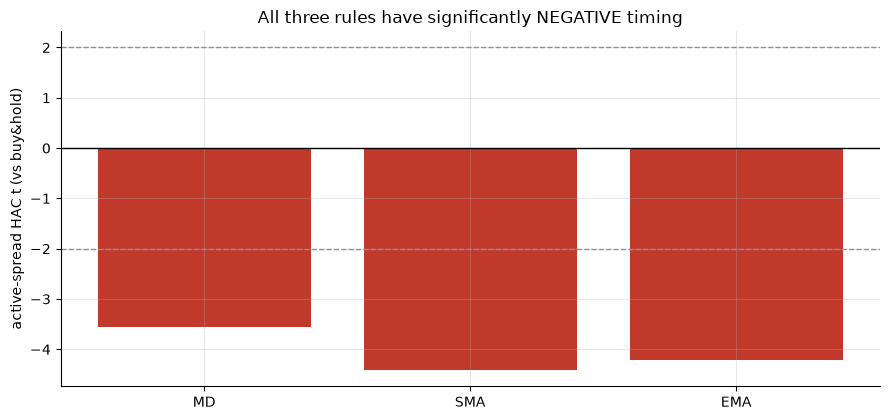

,rule,sharpe_net,spread_bps,spread_t,sw/yr
0,MD,0.380,-3.014,-3.547,25.497
1,SMA,0.238,-3.703,-4.416,36.462
2,EMA,0.267,-3.574,-4.216,38.320
3,B&H,0.647,0.000,NaN,0.000


In [3]:
if HAVE_REAL:
    res = st.run_experiment(tape('SPY'), md_n=MD_N, sma_period=MD_N, ema_period=MD_N,
                            cost_bps=5.0)
    rows = [(k, res[k]['sharpe_net'], res[k]['mean_spread_bps'], res[k]['spread_t'],
             res[k]['switches_per_yr']) for k in ('MD','SMA','EMA')]
    rows.append(('B&H', res['MD']['bh_sharpe'], 0.0, float('nan'), 0.0))
    tbl = pd.DataFrame(rows, columns=['rule','sharpe_net','spread_bps','spread_t','sw/yr'])
else:
    tbl = pd.DataFrame({
        'rule': ['MD','SMA','EMA','B&H'],
        'sharpe_net': [0.38,0.238,0.267,0.647],
        'spread_bps': [-3.01,-3.7,-3.57,0.0],
        'spread_t': [-3.55,-4.42,-4.22,float('nan')],
        'sw/yr': [25.5,36.5,38.3,0.0]})
fig, ax = plt.subplots(figsize=(9.0, 4.3))
sub = tbl[tbl['rule']!='B&H']
col = [RED if t < 0 else GREY for t in sub['spread_t']]
ax.bar(sub['rule'], sub['spread_t'], color=col)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('active-spread HAC t (vs buy&hold)')
ax.set_title('All three rules have significantly NEGATIVE timing')
plt.tight_layout(); plt.show()
tbl.round(3)

> 💡 In plain words: every timing rule's active spread is significantly negative — none beats holding. MD is *not* the worst here (*t* = -3.55 vs SMA's -4.42 and EMA's -4.22) — the brake's lower turnover trims some of the damage — but "less bad" is not the same as "real."

### 4c · Head-to-head — does MD beat the plain MAs it claims to?

The literal claim isn't just "beats holding" — it's "beats a fixed SMA/EMA of the same length." HAC *t* of the MD-minus-SMA and MD-minus-EMA daily net-return spread.

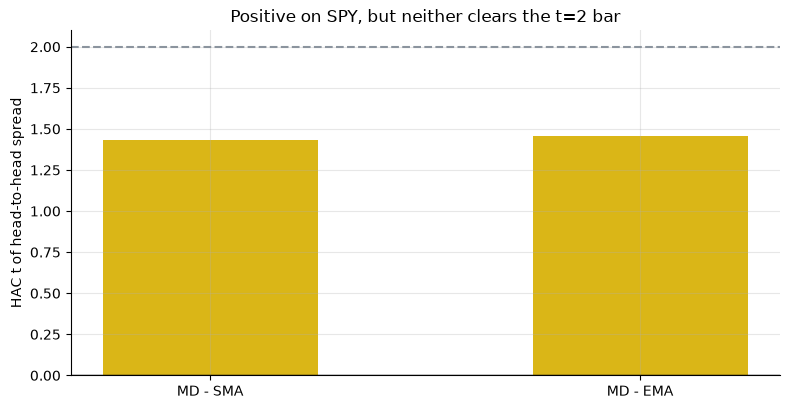

MD-SMA: +0.69 bps/day, t=+1.43
MD-EMA: +0.56 bps/day, t=+1.46


In [4]:
if HAVE_REAL:
    d_sma_bps, d_sma_t = res['diff_md_sma_bps'], res['diff_md_sma_t']
    d_ema_bps, d_ema_t = res['diff_md_ema_bps'], res['diff_md_ema_t']
else:
    d_sma_bps, d_sma_t = R['diff_md_sma_bps'], R['diff_md_sma_t']
    d_ema_bps, d_ema_t = R['diff_md_ema_bps'], R['diff_md_ema_t']
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(['MD - SMA', 'MD - EMA'], [d_sma_t, d_ema_t], color=AMBER, width=.5)
ax.axhline(2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t of head-to-head spread')
ax.set_title('Positive on SPY, but neither clears the t=2 bar')
plt.tight_layout(); plt.show()
print(f'MD-SMA: {d_sma_bps:+.2f} bps/day, t={d_sma_t:+.2f}')
print(f'MD-EMA: {d_ema_bps:+.2f} bps/day, t={d_ema_t:+.2f}')

> 💡 In plain words: MD beats SMA by +0.69 bps/day and EMA by +0.56 bps/day on SPY — real economic size, but *t* = 1.43 / 1.46, both under the bar. The per-instrument table below shows this is the pattern: usually positive, rarely certifiable.

### 4d · The whipsaw count — the one part of the claim that survives

Position changes per year. Unlike Hull MA (+87% vs SMA) and KAMA (+66% vs SMA), the McGinley brake genuinely reduces turnover.

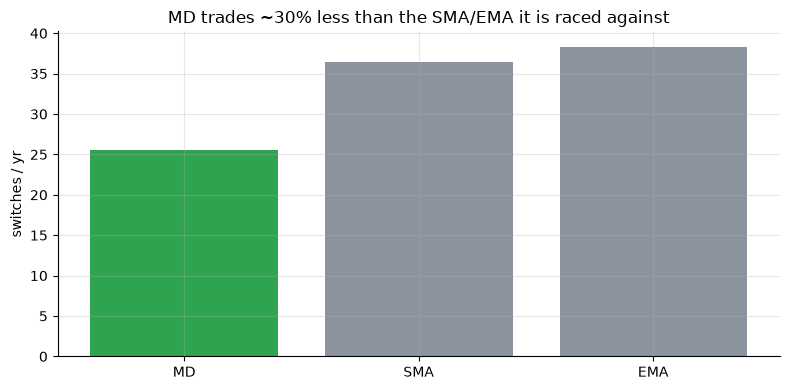

MD/SMA switch ratio: 0.70x   MD/EMA ratio: 0.67x


In [5]:
if HAVE_REAL:
    sw = {k: res[k]['switches_per_yr'] for k in ('MD','SMA','EMA')}
else:
    sw = dict(MD=R['md_sw'], SMA=R['sma_sw'], EMA=R['ema_sw'])
fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.bar(['MD','SMA','EMA'], [sw['MD'],sw['SMA'],sw['EMA']], color=[GREEN, GREY, GREY])
ax.set_ylabel('switches / yr')
ax.set_title('MD trades ~30% less than the SMA/EMA it is raced against')
plt.tight_layout(); plt.show()
print(f"MD/SMA switch ratio: {sw['MD']/sw['SMA']:.2f}x   MD/EMA ratio: {sw['MD']/sw['EMA']:.2f}x")

> 💡 In plain words: 25.5 vs 36.5/38.3 switches/yr — the quartic brake resists chasing noise, and the trade count really does drop. Combined with 4a, the mechanism is internally consistent (a slower, less reactive line trades less) — it just isn't the mechanism advertised ("speeds up to keep pace").

### 4e · Permutation placebo — timing vs exposure

Circularly shift the realised MD position path 2,000×; the statistic is the gross active spread. If the timing is informative, the real spread beats the placebo distribution.

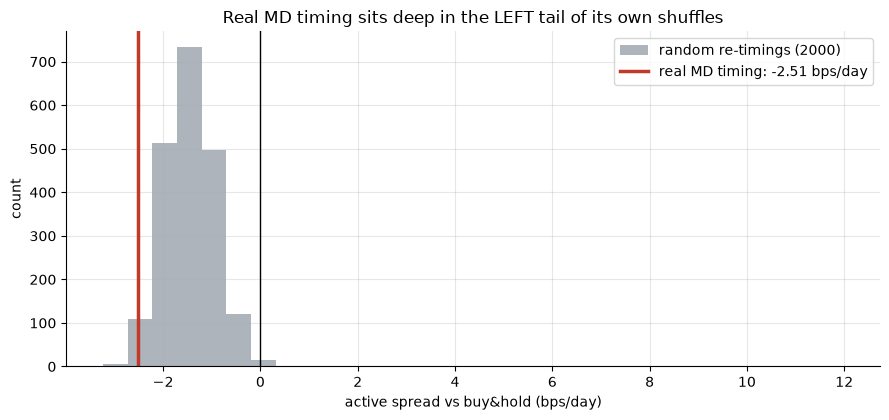

observed -2.51 | placebo mean -1.43 | one-sided p = 0.9895


In [6]:
if HAVE_REAL:
    p = st.permutation_pvalue(tape('SPY')['close'].pct_change(),
                              st.md_position(tape('SPY')['close'], MD_N),
                              cost_bps=0.0, n_perm=2000, seed=672)
    obs, plac, pv = p['observed_spread_bps'], p['placebo_mean_bps'], p['p_value']
    rng = np.random.default_rng(672)
    a = tape('SPY')['close'].pct_change().fillna(0).to_numpy()
    held = st.md_position(tape('SPY')['close'], MD_N).shift(1).fillna(0).to_numpy()
    draws = []
    for _ in range(2000):
        h = np.roll(held, int(rng.integers(1, len(held))))
        turn = np.abs(np.diff(h, prepend=0.0))
        draws.append(((h * a - turn * 0) - a).mean() * 1e4)
else:
    obs, plac, pv = -2.51, -1.43, 0.9895
    draws = list(np.random.default_rng(1).normal(-1.43, 0.55, 2000))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=30, color=GREY, alpha=.7, label='random re-timings (2000)')
ax.axvline(obs, c=RED, lw=2.5, label=f'real MD timing: {obs:+.2f} bps/day')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('active spread vs buy&hold (bps/day)'); ax.set_ylabel('count')
ax.set_title('Real MD timing sits deep in the LEFT tail of its own shuffles')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f} | placebo mean {plac:+.2f} | one-sided p = {pv:.4f}')

> 💡 In plain words: *p* = 0.9895 — essentially every random re-timing of MD's own trades beats the real ones. Fewer trades did not mean *better-placed* trades.

### 4f · Per-instrument & in/out-of-sample — is it ever positive?

Active-spread *t* (vs buy&hold) and MD-vs-SMA/EMA head-to-head *t* on all five tapes, and the SPY first-vs-second-half split.

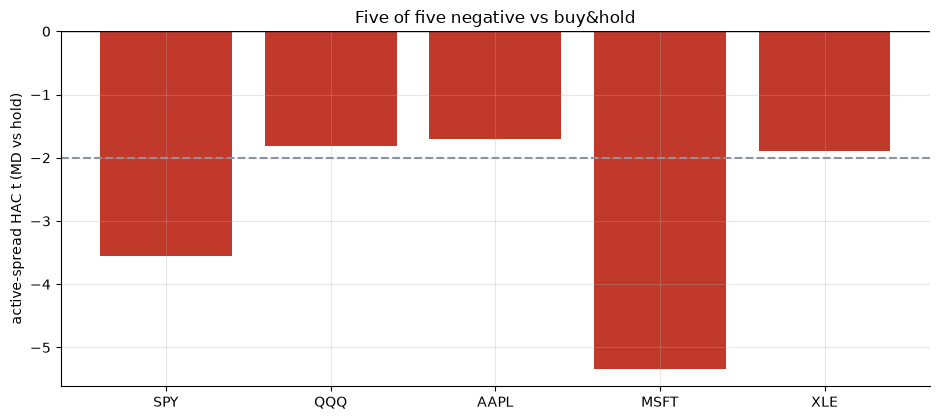

SPY split  H1 t = -1.89 | H2 t = -3.09  (both negative)


,ticker,md_sharpe,bh_sharpe,spread_bps,t,md_sma_t,md_ema_t
0,SPY,0.380,0.647,-3.014,-3.547,1.431,1.457
1,QQQ,0.470,0.521,-2.289,-1.812,2.380,2.747
2,AAPL,0.632,0.623,-2.691,-1.698,0.128,-0.301
3,MSFT,0.494,0.821,-5.890,-5.348,0.750,0.693
4,XLE,0.269,0.428,-2.776,-1.894,1.257,2.094


In [7]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        rr = st.run_experiment(tape(t), md_n=MD_N, sma_period=MD_N, ema_period=MD_N,
                               cost_bps=5.0)
        m = rr['MD']
        recs.append((t, m['sharpe_net'], m['bh_sharpe'], m['mean_spread_bps'], m['spread_t'],
                     rr['diff_md_sma_t'], rr['diff_md_ema_t']))
    per = pd.DataFrame(recs, columns=['ticker','md_sharpe','bh_sharpe','spread_bps','t',
                                       'md_sma_t','md_ema_t'])
    spy = tape('SPY'); half = len(spy)//2
    h1 = st.run_experiment(spy.iloc[:half], md_n=MD_N, cost_bps=5.0)['MD']
    h2 = st.run_experiment(spy.iloc[half:], md_n=MD_N, cost_bps=5.0)['MD']
    split = (h1['spread_t'], h2['spread_t'])
else:
    per = pd.DataFrame({'ticker': ['SPY', 'QQQ', 'AAPL', 'MSFT', 'XLE'], 'md_sharpe': [0.38, 0.47, 0.632, 0.494, 0.269], 'bh_sharpe': [0.647, 0.521, 0.623, 0.821, 0.428], 'spread_bps': [-3.01, -2.29, -2.69, -5.89, -2.78], 't': [-3.55, -1.81, -1.7, -5.35, -1.89], 'md_sma_t': [1.43, 2.38, 0.13, 0.75, 1.26], 'md_ema_t': [1.46, 2.75, -0.3, 0.69, 2.09]})
    split = (-1.89, -3.09)
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.bar(per['ticker'], per['t'], color=RED)
ax.axhline(-2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('active-spread HAC t (MD vs hold)')
ax.set_title('Five of five negative vs buy&hold')
plt.tight_layout(); plt.show()
print('SPY split  H1 t = %.2f | H2 t = %.2f  (both negative)' % split)
per.round(3)

> 💡 In plain words: every instrument's MD timing trails buy-and-hold, and SPY loses in both halves (H1 *t* = -1.89, H2 *t* = -3.09) — not a one-regime artefact. Against SMA/EMA (the fair comparator), only QQQ (both) and XLE (vs EMA) clear *t* = 2 — real, but sparse.

## 5 · The verdict

- **Signal `NONE`** — active spread -3.01 bps/day, HAC *t* -3.55 (gross -2.98); permutation *p* = 0.9895; negative on 5/5 tapes and both halves.
- **Tradability `MIRAGE`** — net Sharpe 0.38 vs hold 0.647; loses gross; long/short Sharpe -0.178, spread -6.08 bps/day (*t* -3.58).
- **Cuts whipsaws & beats a plain MA? `MIXED`** — 25.5 vs 36.5/38.3 switches/yr (a real ~30% cut); but the tracking-distance and step-response checks show the *mechanism* runs backwards, and the head-to-head edge vs SMA/EMA clears *t* = 2 on only 3 of 10 basket comparisons.

## 6 · Could you trade it? — the cost landscape

The spread is below zero before costs; there is no break-even, and the long/short version compounds the loss:

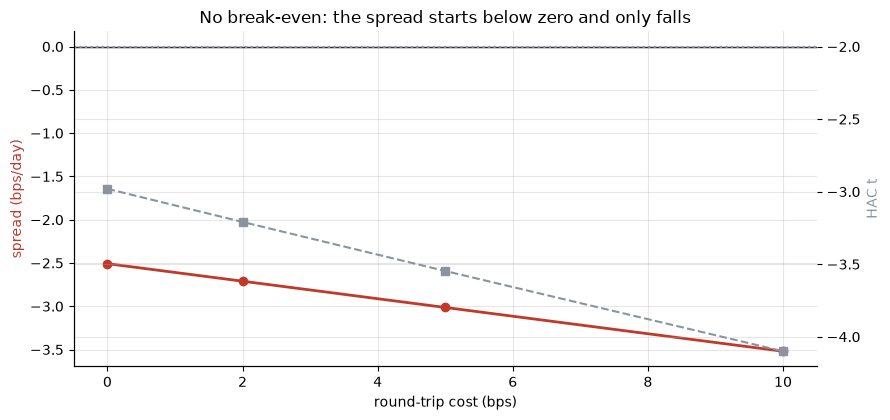

long/short net Sharpe: -0.178 (worse than long/flat)


In [8]:
if HAVE_REAL:
    costs = [0.0, 2.0, 5.0, 10.0]
    spr = [st.run_experiment(tape('SPY'), md_n=MD_N, cost_bps=c)['MD']['mean_spread_bps']
           for c in costs]
    tst = [st.run_experiment(tape('SPY'), md_n=MD_N, cost_bps=c)['MD']['spread_t']
           for c in costs]
    lsr = st.run_experiment(tape('SPY'), md_n=MD_N, cost_bps=5.0, long_short=True)['MD']
    ls_sh = lsr['sharpe_net']
else:
    costs = [0.0, 2.0, 5.0, 10.0]; spr = [-2.51, -2.71, -3.01, -3.52]; tst = [-2.98, -3.21, -3.55, -4.1]
    ls_sh = -0.178
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, spr, 'o-', c=RED, lw=2, label='active spread (bps/day)')
ax2 = ax.twinx(); ax2.plot(costs, tst, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('spread (bps/day)', color=RED)
ax2.set_ylabel('HAC t', color=GREY)
ax.set_title('No break-even: the spread starts below zero and only falls')
plt.tight_layout(); plt.show()
print(f'long/short net Sharpe: {ls_sh:+.3f} (worse than long/flat)')

## 7 · Going further — the positive control

Is the *engine* able to find a trend, or is it always negative? Plant a persistent regime-switching trend in a synthetic tape and sweep the knob; the null (edge=0) is checked over 20 seeds, never a single stream.

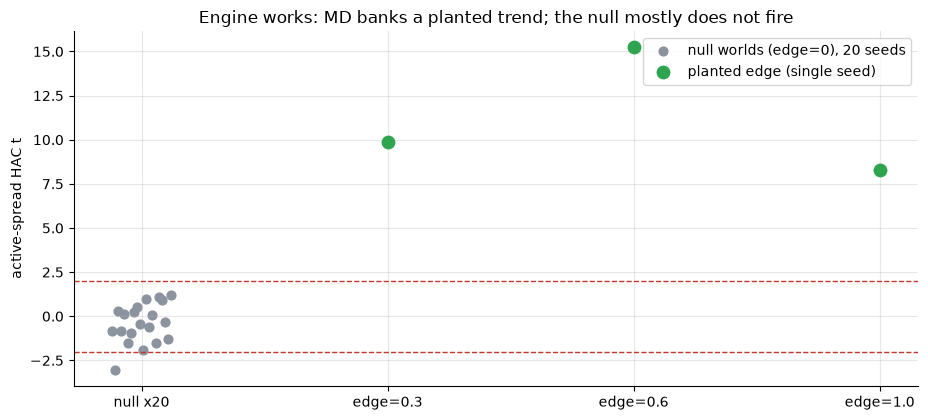

null: mean t = -0.39 (sd 1.12), |t|>=2 in 1/20 seeds
planted: {0.3: 9.86, 0.6: 15.23, 1.0: 8.27}


In [9]:
null_ts = []
for s_ in range(20):
    b, _ = data.synthetic_panel(n_days=6000, edge=0.0, seed=672 + s_)
    null_ts.append(st.run_experiment(b, md_n=MD_N, cost_bps=0.0)['MD']['spread_t'])
null_ts = np.asarray(null_ts)
edges = [0.3, 0.6, 1.0]
sp, tt = [], []
for e in edges:
    b, _ = data.synthetic_panel(n_days=6000, edge=e, seed=672)
    r = st.run_experiment(b, md_n=MD_N, cost_bps=0.0)['MD']
    sp.append(r['mean_spread_bps']); tt.append(r['spread_t'])
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (edge=0), 20 seeds')
ax.scatter(range(1, 1 + len(edges)), tt, color=GREEN, s=80, zorder=5,
           label='planted edge (single seed)')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks(range(0, 1 + len(edges)))
ax.set_xticklabels(['null x20'] + [f'edge={e}' for e in edges])
ax.set_ylabel('active-spread HAC t')
ax.set_title('Engine works: MD banks a planted trend; the null mostly does not fire')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
print('planted:', {e: round(t, 2) for e, t in zip(edges, tt)})

The engine is a faithful trend detector: plant a real persistent trend and MD banks it, clearing *t* = 2 comfortably at every planted level (up to *t* ≈ +15); with no trend planted the null fires on only 1/20 independent seeds — in line with the ~5% false-positive rate expected at a *t* = 2 threshold, not systematic bias. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)* The real-tape verdict is therefore a statement about the **market and the mechanism** — the brake genuinely resists noise (fewer trades) but at the cost of tracking price worse, and daily US equity trends aren't large enough, often enough, for that trade-off to pay. Forks worth trying: a longer $N$, weekly bars, or using the brake as a *volatility filter* (widen/narrow a band) rather than a crossover line.